In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

In [2]:
rents = pd.read_csv(PROCESSED_DATA_DIR / "rent_apr_2026.csv")
house_prices = pd.read_csv(PROCESSED_DATA_DIR / "house_prices_apr_2026.csv")
income = pd.read_csv(PROCESSED_DATA_DIR / "income_2025.csv")

In [3]:
rents_la = rents[rents["area_code"].str.startswith(("E06", "E07", "E08", "E09", "W06"), na=False)].copy()

house_prices_la = house_prices[
    house_prices["area_code"].str.startswith(("E06", "E07", "E08", "E09", "W06"), na=False)
].copy()

In [4]:
rent_house = rents_la.merge(
    house_prices_la,
    on="area_code",
    how="inner",
    suffixes=("_rent", "_house")
)

rent_house.shape

(316, 8)

In [5]:
rent_house["area_name_key"] = rent_house["area_name_rent"].str.lower().str.strip()
income["area_name_key"] = income["area_name"].str.lower().str.strip()

In [6]:
model_base = rent_house.merge(
    income[["area_name_key", "median_annual_pay", "income_confidence_pct"]],
    on="area_name_key",
    how="left"
)

model_base.head()

,date_rent,area_code,area_name_rent,average_monthly_rent,region,date_house,area_name_house,average_house_price,area_name_key,median_annual_pay,income_confidence_pct
0,2026-04-01,E06000001,Hartlepool,566,North East,2026-04-01,Hartlepool,129129,hartlepool,28830.0,6.7
1,2026-04-01,E06000002,Middlesbrough,709,North East,2026-04-01,Middlesbrough,139005,middlesbrough,30253.0,5.5
2,2026-04-01,E06000003,Redcar and Cleveland,644,North East,2026-04-01,Redcar and Cleveland,154422,redcar and cleveland,28630.0,6.5
3,2026-04-01,E06000004,Stockton-on-Tees,736,North East,2026-04-01,Stockton-on-Tees,169540,stockton-on-tees,29877.0,6.9
4,2026-04-01,E06000005,Darlington,671,North East,2026-04-01,Darlington,156880,darlington,30100.0,8.4


In [7]:
model_base["median_annual_pay"].isna().sum()

np.int64(0)

In [8]:
model_base.loc[
    model_base["median_annual_pay"].isna(),
    ["area_code", "area_name_rent", "area_name_house"]
].sort_values("area_name_rent")

,area_code,area_name_rent,area_name_house


In [9]:
model_base.to_csv(PROCESSED_DATA_DIR / "rent_prediction_base.csv", index=False)

In [10]:
model_base[["average_monthly_rent", "average_house_price", "median_annual_pay"]].describe()

,average_house_price,median_annual_pay
count,3.160000e+02,316.000000
mean,3.204903e+05,33417.490506
std,1.413384e+05,4497.483084
min,1.291290e+05,25179.000000
25%,2.187532e+05,30063.000000
50%,2.885490e+05,32441.500000
75%,3.889245e+05,35990.250000
max,1.272760e+06,49310.000000


In [11]:
model_base["average_monthly_rent"] = pd.to_numeric(model_base["average_monthly_rent"], errors="coerce")

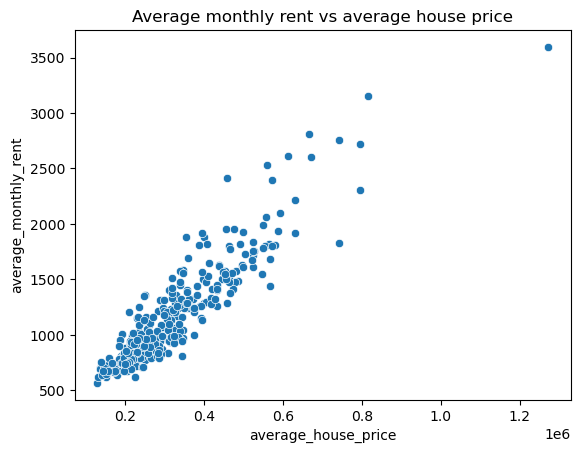

In [12]:
sns.scatterplot(
    data=model_base,
    x="average_house_price",
    y="average_monthly_rent"
)
plt.title("Average monthly rent vs average house price")
plt.show()

In [13]:
model_base[[
    "average_monthly_rent",
    "average_house_price",
    "median_annual_pay"
]].corr()

,average_monthly_rent,average_house_price,median_annual_pay
average_monthly_rent,1.000000,0.915441,0.785299
average_house_price,0.915441,1.000000,0.812933
median_annual_pay,0.785299,0.812933,1.000000


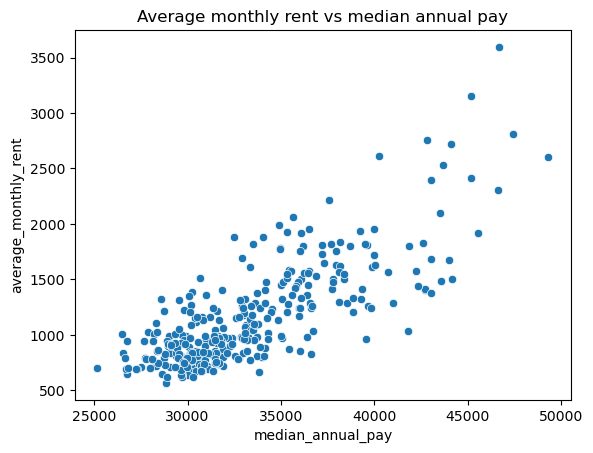

In [14]:
sns.scatterplot(
    data=model_base,
    x="median_annual_pay",
    y="average_monthly_rent"
)
plt.title("Average monthly rent vs median annual pay")
plt.show()

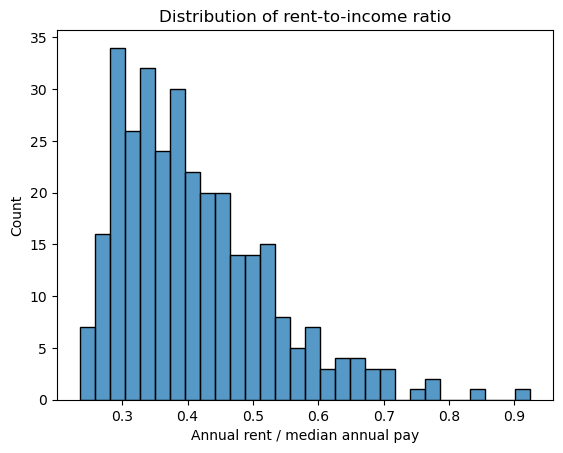

In [15]:
model_base["rent_to_income_ratio"] = (
    model_base["average_monthly_rent"] * 12
) / model_base["median_annual_pay"]

sns.histplot(model_base["rent_to_income_ratio"], bins=30)
plt.title("Distribution of rent-to-income ratio")
plt.xlabel("Annual rent / median annual pay")
plt.show()

In [16]:
model_base.to_csv(PROCESSED_DATA_DIR / "rent_prediction_base.csv", index=False)